In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier 
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, matthews_corrcoef,roc_auc_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [2]:
datafile = "qsar-biodeg.csv"
df = pd.read_csv(datafile, header = 0)
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V33,V34,V35,V36,V37,V38,V39,V40,V41,Class
0,3.919,2.6909,0,0,0,0,0,31.4,2,0,...,0,0,0,2.949,1.591,0,7.253,0,0,2
1,4.170,2.1144,0,0,0,0,0,30.8,1,1,...,0,0,0,3.315,1.967,0,7.257,0,0,2
2,3.932,3.2512,0,0,0,0,0,26.7,2,4,...,0,0,1,3.076,2.417,0,7.601,0,0,2
3,3.000,2.7098,0,0,0,0,0,20.0,0,2,...,0,0,1,3.046,5.000,0,6.690,0,0,2
4,4.236,3.3944,0,0,0,0,0,29.4,2,4,...,0,0,0,3.351,2.405,0,8.003,0,0,2


In [3]:
x = df.loc[:, df.columns != 'Class']
y = df.Class

In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1) 

In [5]:
x_train.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41
count,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,...,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000
mean,4.796936,3.061358,0.705962,0.051491,1.031165,0.300813,1.631436,37.085772,1.432249,1.841463,...,0.140921,0.880759,1.336043,0.953930,3.899220,2.553535,0.691057,8.622102,0.054201,0.689702
std,0.532635,0.824610,1.466586,0.285429,2.538251,1.043959,2.165397,8.907636,1.885858,1.796443,...,0.704072,1.546874,2.426857,1.232989,0.941877,0.630999,1.089957,1.198452,0.333217,2.160438
min,2.000000,0.803900,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,2.267000,1.500000,0.000000,4.917000,0.000000,0.000000
25%,4.499000,2.514825,0.000000,0.000000,0.000000,0.000000,0.000000,30.825000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,3.490750,2.100000,0.000000,8.001500,0.000000,0.000000
50%,4.836500,3.029050,0.000000,0.000000,0.000000,0.000000,1.000000,37.500000,1.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,3.724500,2.444000,0.000000,8.497000,0.000000,0.000000
75%,5.136250,3.439875,1.000000,0.000000,1.000000,0.000000,3.000000,42.900000,2.000000,3.000000,...,0.000000,1.750000,2.000000,2.000000,3.976750,2.898250,1.000000,9.052750,0.000000,0.000000
max,6.496000,7.918400,12.000000,3.000000,36.000000,13.000000,14.000000,60.000000,18.000000,12.000000,...,8.000000,12.000000,18.000000,6.000000,10.695000,5.750000,8.000000,14.700000,4.000000,27.000000


In [6]:
#Padroniza os dados de entrada
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(x_train)
x_train = scaler.transform(x_train)

In [7]:
pd.DataFrame(x_train).describe()

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
count,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,...,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000
mean,0.622094,0.317304,0.058830,0.017164,0.028643,0.023139,0.116531,0.618096,0.079569,0.153455,...,0.017615,0.073397,0.074225,0.158988,0.193666,0.247891,0.086382,0.378729,0.013550,0.025545
std,0.118469,0.115906,0.122215,0.095143,0.070507,0.080305,0.154671,0.148461,0.104770,0.149704,...,0.088009,0.128906,0.134825,0.205498,0.111756,0.148470,0.136245,0.122504,0.083304,0.080016
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.555827,0.240484,0.000000,0.000000,0.000000,0.000000,0.000000,0.513750,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.145201,0.141176,0.000000,0.315292,0.000000,0.000000
50%,0.630894,0.312763,0.000000,0.000000,0.000000,0.000000,0.071429,0.625000,0.055556,0.166667,...,0.000000,0.000000,0.000000,0.166667,0.172935,0.222118,0.000000,0.365941,0.000000,0.000000
75%,0.697565,0.370507,0.083333,0.000000,0.027778,0.000000,0.214286,0.715000,0.111111,0.250000,...,0.000000,0.145833,0.111111,0.333333,0.202865,0.329000,0.125000,0.422749,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
#Inicializa a classe RandomForest
rf = RandomForestClassifier()

#Elenca os hiperparâmetros a serem testados para a RandomForest
parameters = {
               'max_depth': [5, 10], 
               'n_estimators': [10, 100],
               'criterion': ['gini', 'entropy'],
                'max_features': ['sqrt', 10]
}

clf = GridSearchCV(rf, parameters, cv = 5, verbose = 2)

In [9]:
#Ajusta o melhor modelo (melhores hiper-parâmetros aos dados de treinamento)
clf.fit(x_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END criterion=gini, max_depth=5, max_features=sqrt, n_estimators=10; total time=   0.0s
[CV] END criterion=gini, max_depth=5, max_features=sqrt, n_estimators=10; total time=   0.0s
[CV] END criterion=gini, max_depth=5, max_features=sqrt, n_estimators=10; total time=   0.0s
[CV] END criterion=gini, max_depth=5, max_features=sqrt, n_estimators=10; total time=   0.0s
[CV] END criterion=gini, max_depth=5, max_features=sqrt, n_estimators=10; total time=   0.0s
[CV] END criterion=gini, max_depth=5, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END criterion=gini, max_depth=5, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END criterion=gini, max_depth=5, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END criterion=gini, max_depth=5, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END criterion=gini, max_depth=5, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV]

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy'], 'max_depth': [5, 10],
                         'max_features': ['sqrt', 10],
                         'n_estimators': [10, 100]},
             verbose=2)

In [10]:
print(clf.best_params_)

{'criterion': 'entropy', 'max_depth': 5, 'max_features': 10, 'n_estimators': 100}


In [11]:
2*2*2*2*5

80

In [12]:
x_test = scaler.transform(x_test)

In [13]:
#Aplica a predição no conjunto de teste
y_pred = clf.predict(x_test)

#Avalia a qualidade do modelo final
print(classification_report(y_test, y_pred)) 
accuracy_score(y_test, y_pred)

              precision    recall  f1-score   support

           1       0.84      0.92      0.88       206
           2       0.82      0.68      0.74       111

    accuracy                           0.84       317
   macro avg       0.83      0.80      0.81       317
weighted avg       0.83      0.84      0.83       317



0.8359621451104101

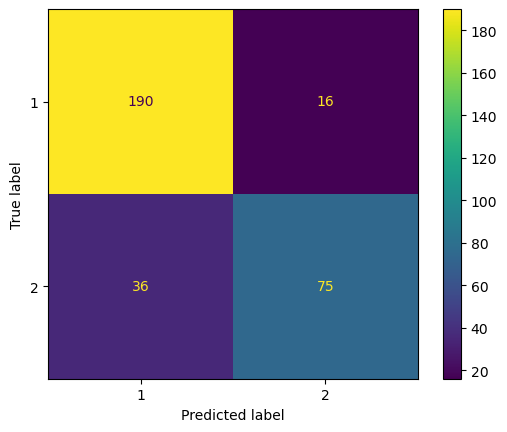

In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(clf, x_test, y_test)

<AxesSubplot: >

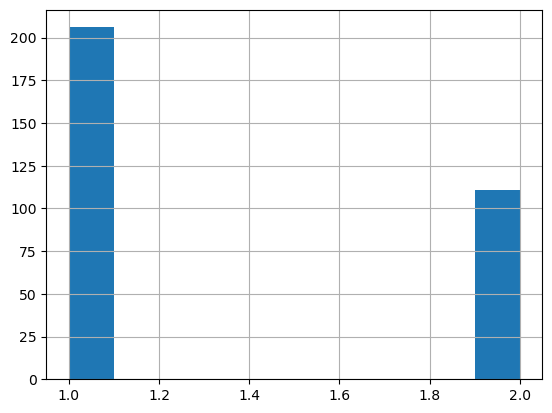

In [15]:
y_test.hist()

In [16]:
from sklearn.metrics import balanced_accuracy_score
balanced_accuracy_score(y_test, y_pred)

0.7990028863815272

In [17]:
rf = RandomForestClassifier()
rf.set_params(**clf.best_params_)

rf.fit(x_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=5, max_features=10)

In [18]:
y_predb = rf.predict_proba(x_test)

In [19]:
y_predb

array([[0.92459135, 0.07540865],
       [0.53174095, 0.46825905],
       [0.78109543, 0.21890457],
       [0.83429819, 0.16570181],
       [0.34436901, 0.65563099],
       [0.89148652, 0.10851348],
       [0.948735  , 0.051265  ],
       [0.4345878 , 0.5654122 ],
       [0.89909256, 0.10090744],
       [0.89447953, 0.10552047],
       [0.96892777, 0.03107223],
       [0.194068  , 0.805932  ],
       [0.85348892, 0.14651108],
       [0.98100017, 0.01899983],
       [0.94575797, 0.05424203],
       [0.76772153, 0.23227847],
       [0.16365064, 0.83634936],
       [0.75201536, 0.24798464],
       [0.29367122, 0.70632878],
       [0.53124232, 0.46875768],
       [0.65523072, 0.34476928],
       [0.94066238, 0.05933762],
       [0.32963401, 0.67036599],
       [0.24786704, 0.75213296],
       [0.17875536, 0.82124464],
       [0.84270834, 0.15729166],
       [0.49838279, 0.50161721],
       [0.92049455, 0.07950545],
       [0.20688014, 0.79311986],
       [0.35424799, 0.64575201],
       [0.

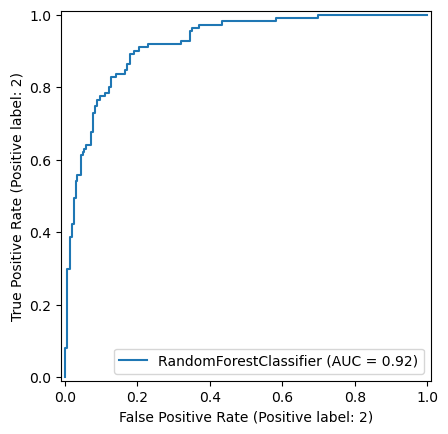

In [20]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(rf, x_test, y_test)

In [21]:
#E o impacto de cada atributo

In [22]:
rf.feature_importances_

array([8.31227004e-02, 1.51583688e-02, 1.79078682e-02, 1.14413432e-03,
       2.60526729e-02, 1.97893892e-02, 2.11972174e-02, 1.95778066e-02,
       2.16374252e-02, 2.66289078e-02, 3.06184064e-02, 3.81474865e-02,
       1.83773813e-02, 1.57102177e-02, 2.91324074e-02, 2.94719817e-02,
       1.54183160e-02, 2.16154706e-02, 1.21438566e-03, 5.84493797e-04,
       0.00000000e+00, 9.25164941e-02, 3.40249047e-03, 1.38884255e-04,
       1.69248927e-03, 5.03084107e-04, 3.86087964e-02, 8.33478362e-03,
       9.03925110e-05, 2.73288285e-02, 1.31622174e-02, 2.28043925e-03,
       2.29389781e-02, 2.86127824e-02, 5.12733111e-03, 1.69448691e-01,
       1.85026872e-02, 4.68385238e-02, 5.51573715e-02, 7.49639678e-03,
       5.31130028e-03])

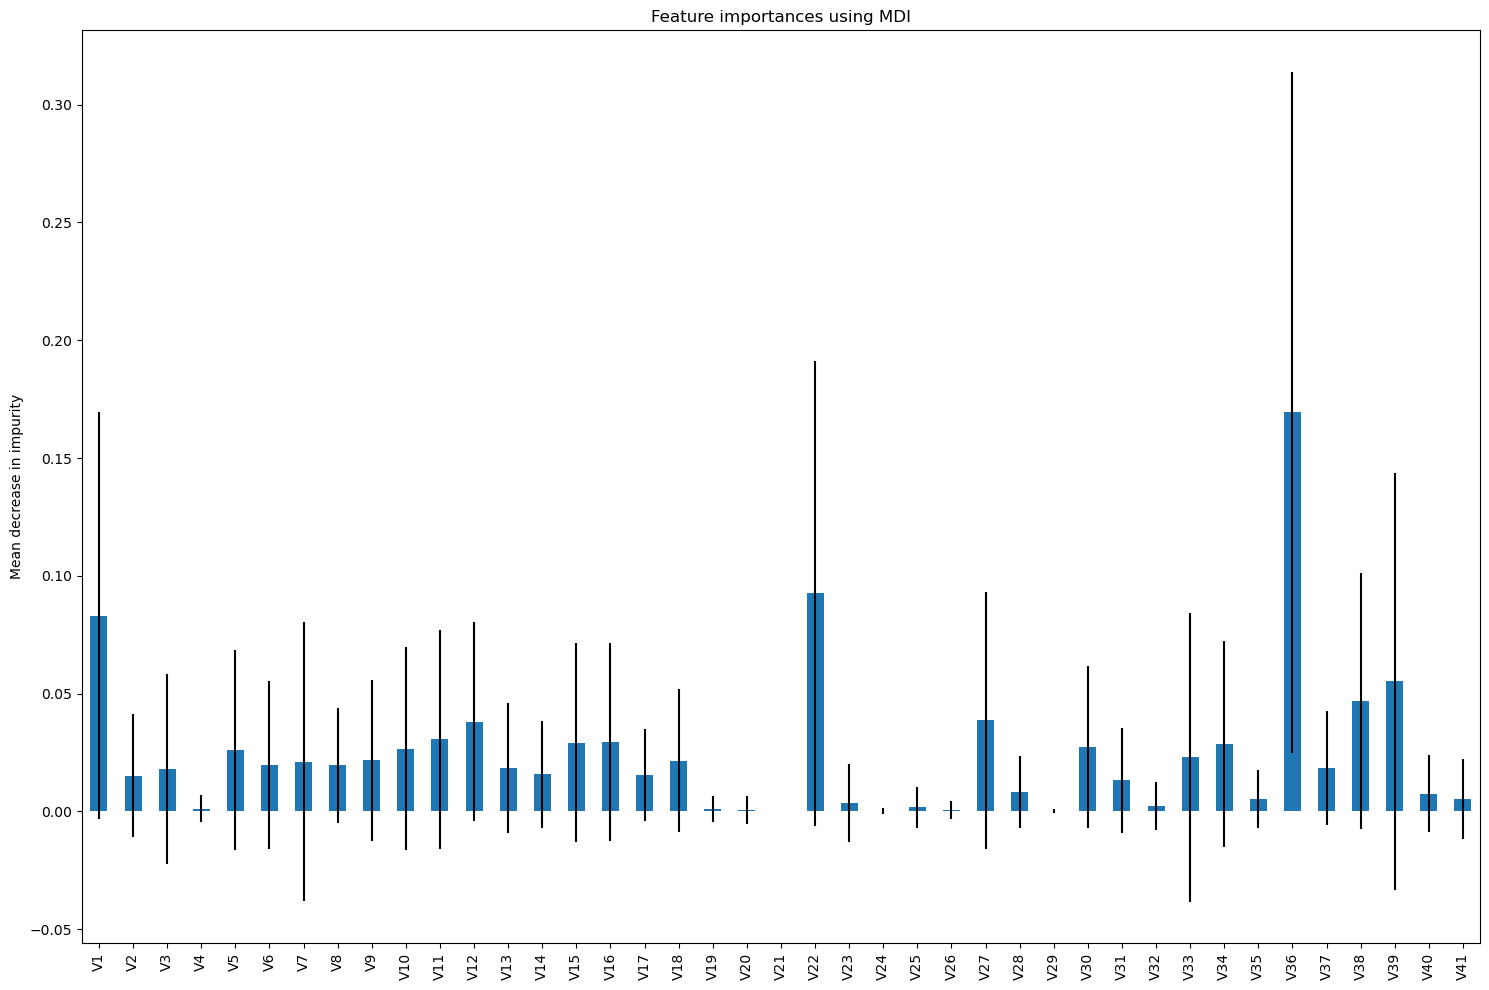

In [23]:
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

feature_names = [f"feature {i}" for i in range(x.shape[1])]
feature_names = x.columns
importances = rf.feature_importances_
forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots(figsize = (15,10))

forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

In [24]:
import shap

ModuleNotFoundError: No module named 'shap'

In [25]:
def f(x):
    return rf.predict_proba(x)[:, 1]


med = pd.DataFrame(x_train).median().values.reshape((1, x_train.shape[1]))

explainer = shap.Explainer(f, med)
shap_values = explainer(pd.DataFrame(x_test).iloc[0:1000, :])

NameError: name 'shap' is not defined

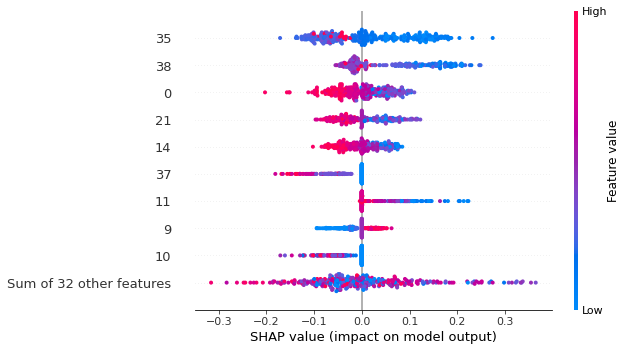

In [64]:
shap.plots.beeswarm(shap_values)